In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import datetime as datetime
import os
import time
import pandas as pd
from binance.client import Client

In [49]:
# Clean Data

PAIRS = [
    ("V", "MA", "Data/V_daily.csv", "Data/MA_daily.csv"),
    ("PEP", "KO", "Data/PEP_daily.csv", "Data/KO_daily.csv"),
    ("XOM", "CVX", "Data/XOM_daily.csv", "Data/CVX_daily.csv"),
    ("JPM", "BAC", "Data/JPM_daily.csv", "Data/BAC_daily.csv"),
    ("GOOG", "GOOGL", "Data/GOOG_daily.csv", "Data/GOOGL_daily.csv"),
    ("SPY", "IVV", "Data/SPY_daily.csv", "Data/IVV_daily.csv"),
    ("GLD", "IAU", "Data/GLD_daily.csv", "Data/IAU_daily.csv"),
    ("AGG", "BND", "Data/AGG_daily.csv", "Data/BND_daily.csv"),
    ("GOOG", "GOOGL", "Data/GOOG_daily.csv", "Data/GOOGL_daily.csv"),
]


def load_yfinance_csv(path, ticker):
    asset = pd.read_csv(path)
    asset = asset.iloc[2:].copy()
    asset = asset.rename(columns={"Price": "Date", "Adj Close": ticker})
    asset = asset[["Date", ticker]].copy()
    asset["Date"] = pd.to_datetime(asset["Date"], errors="coerce")
    asset[ticker] = pd.to_numeric(asset[ticker], errors="coerce")
    asset = asset.dropna(subset=["Date", ticker])
    return asset


pair_data = {}

for y_ticker, x_ticker, y_path, x_path in PAIRS:
    y_asset = load_yfinance_csv(y_path, y_ticker)
    x_asset = load_yfinance_csv(x_path, x_ticker)

    pair_df = y_asset.merge(x_asset, on="Date", how="inner")
    pair_df = pair_df.sort_values("Date").reset_index(drop=True)
    pair_df = pair_df[(pair_df[y_ticker] > 0) & (pair_df[x_ticker] > 0)].copy()

    pair_df[f"log_{y_ticker}"] = np.log(pair_df[y_ticker])
    pair_df[f"log_{x_ticker}"] = np.log(pair_df[x_ticker])
    pair_df = pair_df.dropna().reset_index(drop=True)

    pair_data[(y_ticker, x_ticker)] = pair_df

In [50]:
# Defining periods for training, validation and testing

TRAIN_START = "2010-01-01"
TRAIN_END = "2018-12-31"

VALID_START = "2019-01-01"
VALID_END = "2021-12-31"

TEST_START = "2022-01-01"

train_pair_data = {
    pair: pair_df[(pair_df["Date"] >= TRAIN_START) & (pair_df["Date"] <= TRAIN_END)].copy()
    for pair, pair_df in pair_data.items()
}
valid_pair_data = {
    pair: pair_df[(pair_df["Date"] >= VALID_START) & (pair_df["Date"] <= VALID_END)].copy()
    for pair, pair_df in pair_data.items()
}
test_pair_data = {
    pair: pair_df[pair_df["Date"] >= TEST_START].copy()
    for pair, pair_df in pair_data.items()
}

In [68]:
# Check for cointegration

def cointegration_gate(y, x, pvalue_threshold=0.1):
    x_const = sm.add_constant(x)
    model = sm.OLS(y, x_const).fit()

    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]

    residual = y - alpha - beta * x

    adf_result = adfuller(residual.dropna())
    adf_stat = adf_result[0]
    adf_pvalue = adf_result[1]

    passed = adf_pvalue < pvalue_threshold

    return {
        "passed": passed,
        "alpha": alpha,
        "beta": beta,
        "residual": residual,
        "adf_stat": adf_stat,
        "adf_pvalue": adf_pvalue,
    }

cointegration_results = {}

for y_ticker, x_ticker, *_ in PAIRS:
    train_df = train_pair_data[(y_ticker, x_ticker)]
    pair_name = f"{y_ticker}/{x_ticker}"

    gate1 = cointegration_gate(
        y=train_df[f"log_{y_ticker}"],
        x=train_df[f"log_{x_ticker}"],
        pvalue_threshold=0.1
    )

    cointegration_results[pair_name] = gate1
    status = "Pass" if gate1["passed"] else "Reject"
    print(f"{pair_name}: {status}; adf_pvalue={gate1['adf_pvalue']:.6f}")

V/MA: Pass; adf_pvalue=0.089567
PEP/KO: Reject; adf_pvalue=0.217909
XOM/CVX: Reject; adf_pvalue=0.403565
JPM/BAC: Pass; adf_pvalue=0.090410
GOOG/GOOGL: Reject; adf_pvalue=0.203545
SPY/IVV: Reject; adf_pvalue=0.218016
GLD/IAU: Reject; adf_pvalue=0.425736
AGG/BND: Reject; adf_pvalue=0.181015
GOOG/GOOGL: Reject; adf_pvalue=0.199062


In [69]:
# Check for quality of mean reversion

def mean_reversion_gate(alpha, min_half_life = 2, max_half_life= 63):
    alpha = alpha.dropna()

    x = alpha.iloc[:-1]
    y = alpha.iloc[1:]

    phi, intercept = np.polyfit(x, y, 1)

    if phi <= 0 or phi >= 1:
        return {
            "passed": False,
            "phi": phi,
            "half_life": np.nan,
            "reason": "Not mean-reverting"
        }

    theta = -np.log(phi)
    half_life = np.log(2) / theta

    passed = min_half_life <= half_life <= max_half_life

    return {
        "passed": passed,
        "phi": phi,
        "theta": theta,
        "half_life": half_life,
        "reason": "Passed" if passed else "Bad half-life"
    }

mean_reversion_results = {}

for y_ticker, x_ticker, *_ in PAIRS:
    train_df = train_pair_data[(y_ticker, x_ticker)]
    pair_name = f"{y_ticker}/{x_ticker}"

    gate1 = cointegration_gate(
        y=train_df[f"log_{y_ticker}"],
        x=train_df[f"log_{x_ticker}"],
        pvalue_threshold=0.1
    )

    gate2 = mean_reversion_gate(
        gate1["residual"],
        min_half_life=2,
        max_half_life=63
    )

    mean_reversion_results[pair_name] = gate2
    status = "Pass" if gate2["passed"] else "Reject"
    print(f"{pair_name}: {status}; half_life={gate2['half_life']:.0f}")

V/MA: Reject; half_life=84
PEP/KO: Reject; half_life=171
XOM/CVX: Reject; half_life=179
JPM/BAC: Reject; half_life=236
GOOG/GOOGL: Pass; half_life=57
SPY/IVV: Pass; half_life=12
GLD/IAU: Pass; half_life=31
AGG/BND: Pass; half_life=31
GOOG/GOOGL: Pass; half_life=13


Only **GOOG/GOOGL** passed both screening gates, so the remaining strategy development focuses on trading that pair.

The **cointegration gate** checks whether the two log-price series form a stationary residual after regression. This is meant to confirm that the pair has a stable long-run relationship rather than simply moving together by chance.

The **mean-reversion gate** checks whether that residual reverts at a usable speed by estimating its half-life. Pairs with residuals that do not mean-revert, or revert too slowly/too quickly for the strategy assumptions, are rejected.


In [53]:
# Estimate dynamic hedge ratio

def kalman_filter_beta(y, x, q_alpha=1e-5, q_beta=1e-5, r=1e-3):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    n = len(y)

    alpha_series = np.full(n, np.nan)
    beta_series = np.full(n, np.nan)
    spread_series = np.full(n, np.nan)

    # Initial state: [alpha, beta]
    theta = np.array([0.0, 1.0])

    P = np.eye(2)

    Q = np.array([
        [q_alpha, 0.0],
        [0.0, q_beta]
    ])

    R = r

    for t in range(n):
        H = np.array([1.0, x[t]])

        theta_pred = theta
        P_pred = P + Q

        y_pred = H @ theta_pred

        innovation = y[t] - y_pred

        S = H @ P_pred @ H.T + R

        K = P_pred @ H.T / S

        theta = theta_pred + K * innovation
        P = P_pred - np.outer(K, H) @ P_pred

        alpha_series[t] = theta[0]
        beta_series[t] = theta[1]
        spread_series[t] = y[t] - theta[0] - theta[1] * x[t]

    return pd.DataFrame({
        "alpha_kalman": alpha_series,
        "beta_kalman": beta_series,
        "spread": spread_series
    })

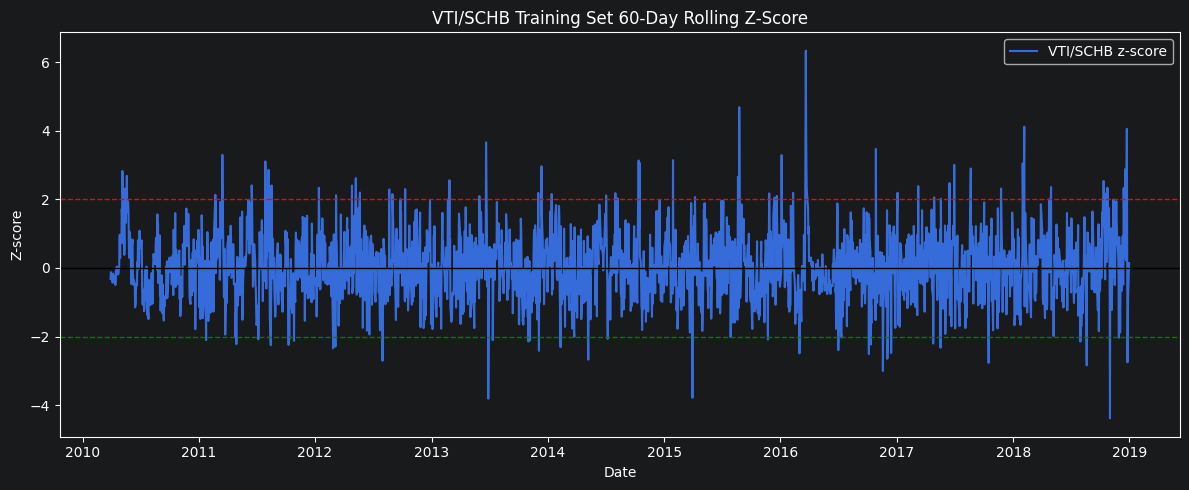

In [54]:
Z_LOOKBACK = 60

training_set = train_pair_data[("GOOG", "GOOGL")].copy().reset_index(drop=True)

kalman_training = kalman_filter_beta(
    y=training_set["log_GOOG"],
    x=training_set["log_GOOGL"]
)

training_set = pd.concat([training_set, kalman_training], axis=1)
training_set["spread_mean"] = training_set["spread"].rolling(Z_LOOKBACK).mean()
training_set["spread_std"] = training_set["spread"].rolling(Z_LOOKBACK).std()
training_set["z"] = (training_set["spread"] - training_set["spread_mean"]) / training_set["spread_std"]

plt.figure(figsize=(12, 5))
plt.plot(training_set["Date"], training_set["z"], label="GOOG/GOOGL z-score")
plt.axhline(0, color="black", linewidth=1)
plt.axhline(2, color="red", linestyle="--", linewidth=1)
plt.axhline(-2, color="green", linestyle="--", linewidth=1)
plt.title("GOOG/GOOGL Training Set 60-Day Rolling Z-Score")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(training_set["Date"], training_set["spread"], label="Kalman training spread")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("GOOG/GOOGL Kalman Training Spread")
axes[0].set_ylabel("Spread")
axes[0].legend()

axes[1].plot(training_set["Date"], training_set["alpha_kalman"], label="Alpha spread", color="tab:orange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("GOOG/GOOGL Alpha Spread")
axes[1].set_ylabel("Alpha")
axes[1].legend()

axes[2].plot(training_set["Date"], training_set["beta_kalman"], label="Beta spread", color="tab:green")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("GOOG/GOOGL Beta Spread")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Beta")
axes[2].legend()

plt.tight_layout()
plt.show()

,period,position_limit,total_pnl,annual_pnl,daily_vol,sharpe,max_drawdown,entries,exposure
0,train,100,25.8875,2.8827,0.0608,2.9847,-0.4939,91,0.1374
1,train,1000,258.8751,28.8275,0.6084,2.9847,-4.9388,91,0.1374
2,train,5000,1294.3755,144.1373,3.0421,2.9847,-24.6942,91,0.1374
3,valid,100,10.0854,3.3618,0.0932,2.2730,-0.8799,32,0.1440
4,valid,1000,100.8538,33.6179,0.9317,2.2730,-8.7988,32,0.1440
5,valid,5000,504.2688,168.0896,4.6584,2.2730,-43.9941,32,0.1440
6,test,100,10.9006,2.4570,0.0488,3.1735,-0.2943,46,0.1349
7,test,1000,109.0056,24.5701,0.4877,3.1735,-2.9428,46,0.1349
8,test,5000,545.0282,122.8507,2.4386,3.1735,-14.7142,46,0.1349


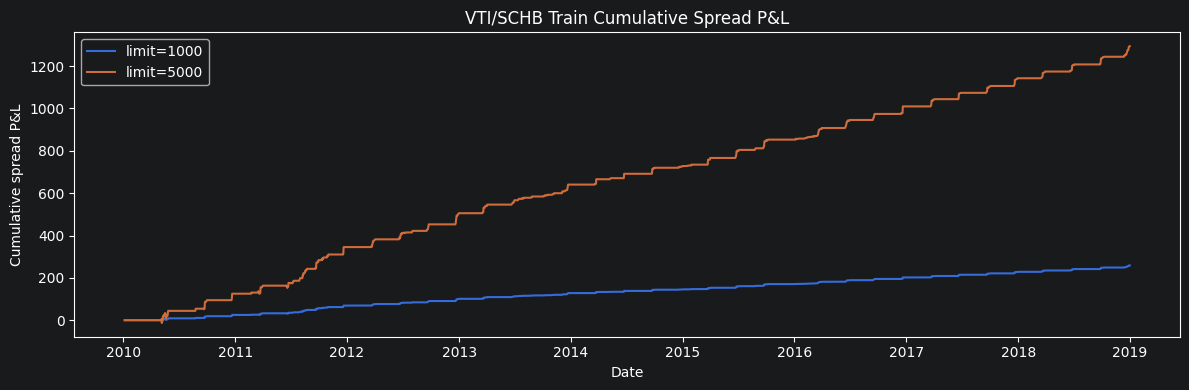

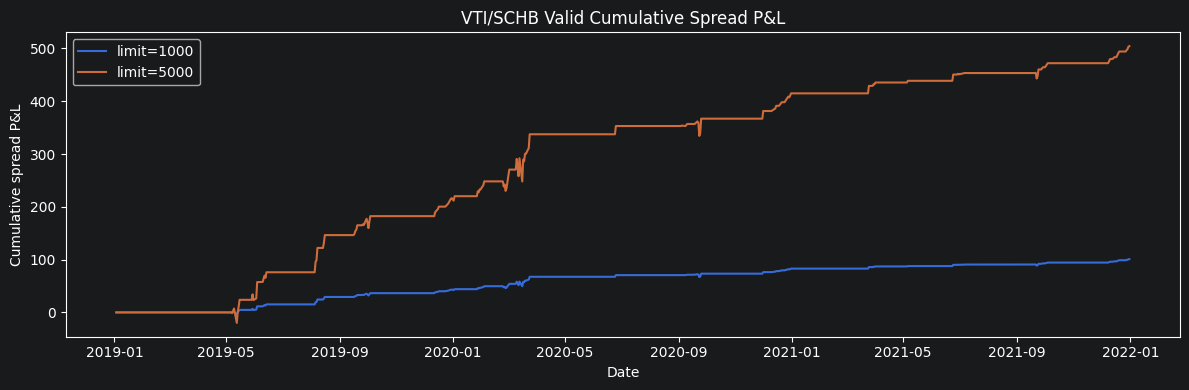

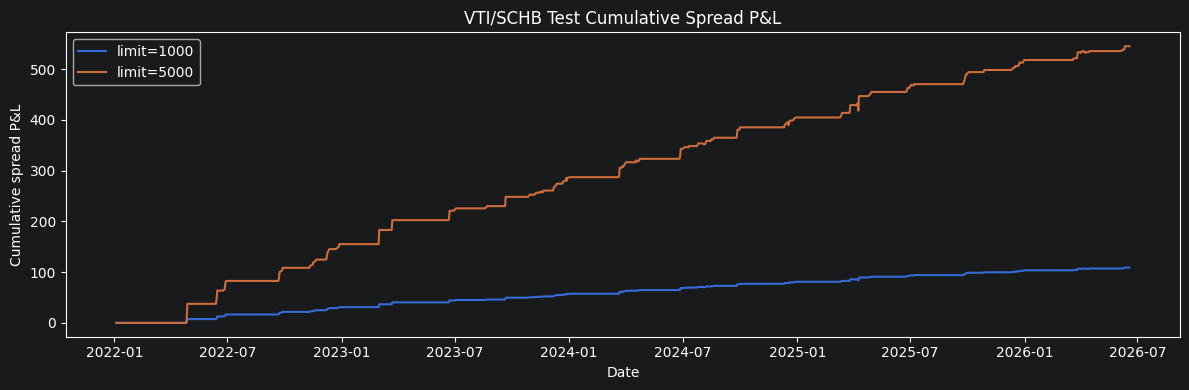

In [43]:
# Basic acktest GOOG/GOOGL z-score strategy with larger position limits

def prepare_vti_schb_set(source_df):
    result = source_df.copy().reset_index(drop=True)
    kalman_result = kalman_filter_beta(
        y=result["log_GOOG"],
        x=result["log_GOOGL"]
    )
    result = pd.concat([result, kalman_result], axis=1)
    result["spread_mean"] = result["spread"].rolling(Z_LOOKBACK).mean()
    result["spread_std"] = result["spread"].rolling(Z_LOOKBACK).std()
    result["z"] = (result["spread"] - result["spread_mean"]) / result["spread_std"]
    return result


def generate_positions(df, entry_z=1.5, exit_z=0.5, position_limit=100):
    result = df.copy()
    positions = []
    current_pos = 0

    for z in result["z"]:
        if pd.isna(z):
            positions.append(current_pos)
            continue

        if current_pos == 0:
            if z > entry_z:
                current_pos = -position_limit
            elif z < -entry_z:
                current_pos = position_limit
        elif current_pos > 0 and z >= -exit_z:
            current_pos = 0
        elif current_pos < 0 and z <= exit_z:
            current_pos = 0

        positions.append(current_pos)

    result["position"] = positions
    return result


def run_spread_backtest(df, position_limit):
    result = generate_positions(df, position_limit=position_limit)
    result["spread_change"] = result["spread"].diff()
    result["pnl"] = result["position"].shift(1).fillna(0) * result["spread_change"]
    result["cum_pnl"] = result["pnl"].cumsum()
    result["drawdown"] = result["cum_pnl"] - result["cum_pnl"].cummax()

    daily_vol = result["pnl"].std()
    sharpe = np.nan if daily_vol == 0 or pd.isna(daily_vol) else np.sqrt(252) * result["pnl"].mean() / daily_vol
    entries = ((result["position"] != 0) & (result["position"].shift(1).fillna(0) == 0)).sum()

    return {
        "position_limit": position_limit,
        "total_pnl": result["pnl"].sum(),
        "annual_pnl": result["pnl"].mean() * 252,
        "daily_vol": daily_vol,
        "sharpe": sharpe,
        "max_drawdown": result["drawdown"].min(),
        "entries": int(entries),
        "exposure": result["position"].ne(0).mean(),
    }


vti_schb_sets = {
    "train": prepare_vti_schb_set(train_pair_data[("GOOG", "GOOGL")]),
    "valid": prepare_vti_schb_set(valid_pair_data[("GOOG", "GOOGL")]),
    "test": prepare_vti_schb_set(test_pair_data[("GOOG", "GOOGL")]),
}

position_limit_results = []

for period_name, period_df in vti_schb_sets.items():
    for position_limit in [100, 1000, 5000]:
        stats = run_spread_backtest(period_df, position_limit)
        stats["period"] = period_name
        position_limit_results.append(stats)

position_limit_results = pd.DataFrame(position_limit_results)
position_limit_results = position_limit_results[
    ["period", "position_limit", "total_pnl", "annual_pnl", "daily_vol", "sharpe", "max_drawdown", "entries", "exposure"]
]

display(position_limit_results.round(4))

for period_name, period_df in vti_schb_sets.items():
    plt.figure(figsize=(12, 4))
    for position_limit in [1000, 5000]:
        backtest_df = generate_positions(period_df, position_limit=position_limit)
        backtest_df["spread_change"] = backtest_df["spread"].diff()
        backtest_df["pnl"] = backtest_df["position"].shift(1).fillna(0) * backtest_df["spread_change"]
        backtest_df["cum_pnl"] = backtest_df["pnl"].cumsum()
        plt.plot(backtest_df["Date"], backtest_df["cum_pnl"], label=f"limit={position_limit}")

    plt.title(f"GOOG/GOOGL {period_name.title()} Cumulative Spread P&L")
    plt.xlabel("Date")
    plt.ylabel("Cumulative spread P&L")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Backtest conclusion

The basic backtest suggests that the GOOG/GOOGL pairs trading strategy may be worth researching further. The pair passed both the cointegration and mean-reversion gates, and the initial spread-based backtest produced positive results across the training, validation, and test periods.

These results are only preliminary. The current backtest is simplified and should be extended with transaction costs, slippage, capital normalization, borrow/financing assumptions, and hyperparameter tuning before drawing any production-level conclusion.


In [64]:
client = Client(tld="us", ping=False)

CRYPTO_PAIRS = [
    ("OPUSDT", "ARBUSDT"),
    ("SUIUSDT", "APTUSDT"),
    ("SOLUSDT", "AVAXUSDT"),
    ("AAVEUSDT", "COMPUSDT"),
    ("UNIUSDT", "SUSHIUSDT"),
    ("BTCUSDT", "ETHUSDT"),
]

INTERVAL = Client.KLINE_INTERVAL_1HOUR
START_DATE = "1 Jan, 2021"
END_DATE = None  # or "1 Jan, 2025"

DATA_DIR = "Crypto_Data"
os.makedirs(DATA_DIR, exist_ok=True)


def unique_symbols_from_pairs(pairs):
    symbols = set()
    for a, b in pairs:
        symbols.add(a)
        symbols.add(b)
    return sorted(symbols)


def download_binance_klines(symbol, interval, start_date, end_date=None):
    """
    Downloads Binance OHLCV kline data for one symbol.
    Returns a clean pandas DataFrame.
    """

    klines = client.get_historical_klines(
        symbol=symbol,
        interval=interval,
        start_str=start_date,
        end_str=end_date,
    )

    columns = [
        "open_time",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_time",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_volume",
        "taker_buy_quote_volume",
        "ignore",
    ]

    df = pd.DataFrame(klines, columns=columns)

    if df.empty:
        return df

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms")

    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_volume",
        "taker_buy_quote_volume",
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.drop(columns=["ignore"])
    df = df.dropna()
    df = df.sort_values("open_time").reset_index(drop=True)

    return df


symbols = unique_symbols_from_pairs(CRYPTO_PAIRS)

for symbol in symbols:
    print(f"Downloading {symbol}...")

    df = download_binance_klines(
        symbol=symbol,
        interval=INTERVAL,
        start_date=START_DATE,
        end_date=END_DATE,
    )

    if df.empty:
        print(f"No data returned for {symbol}")
        continue

    output_path = os.path.join(DATA_DIR, f"{symbol}_{INTERVAL}.csv")
    df.to_csv(output_path, index=False)

    print(f"Saved {symbol}: {len(df)} rows -> {output_path}")

    # Be polite to the API
    time.sleep(0.25)

Saved AAVEUSDT: 43317 rows -> Crypto_Data/AAVEUSDT_1h.csv
Saved APTUSDT: 31582 rows -> Crypto_Data/APTUSDT_1h.csv
Saved ARBUSDT: 27725 rows -> Crypto_Data/ARBUSDT_1h.csv
Saved AVAXUSDT: 40293 rows -> Crypto_Data/AVAXUSDT_1h.csv
Saved BTCUSDT: 48000 rows -> Crypto_Data/BTCUSDT_1h.csv
Saved COMPUSDT: 48000 rows -> Crypto_Data/COMPUSDT_1h.csv
Saved ETHUSDT: 48000 rows -> Crypto_Data/ETHUSDT_1h.csv
Saved OPUSDT: 35086 rows -> Crypto_Data/OPUSDT_1h.csv
Saved SOLUSDT: 48000 rows -> Crypto_Data/SOLUSDT_1h.csv
Saved SUIUSDT: 23360 rows -> Crypto_Data/SUIUSDT_1h.csv
Saved SUSHIUSDT: 38769 rows -> Crypto_Data/SUSHIUSDT_1h.csv
Saved UNIUSDT: 48000 rows -> Crypto_Data/UNIUSDT_1h.csv


In [65]:
# Crypto pairs for research

crypto_pairs = [
    ("OPUSDT", "ARBUSDT", "Crypto_Data/OPUSDT_1h.csv", "Crypto_Data/ARBUSDT_1h.csv"),
    ("SUIUSDT", "APTUSDT", "Crypto_Data/SUIUSDT_1h.csv", "Crypto_Data/APTUSDT_1h.csv"),
    ("SOLUSDT", "AVAXUSDT", "Crypto_Data/SOLUSDT_1h.csv", "Crypto_Data/AVAXUSDT_1h.csv"),
    ("AAVEUSDT", "COMPUSDT", "Crypto_Data/AAVEUSDT_1h.csv", "Crypto_Data/COMPUSDT_1h.csv"),
    ("UNIUSDT", "SUSHIUSDT", "Crypto_Data/UNIUSDT_1h.csv", "Crypto_Data/SUSHIUSDT_1h.csv"),
    ("BTCUSDT", "ETHUSDT", "Crypto_Data/BTCUSDT_1h.csv", "Crypto_Data/ETHUSDT_1h.csv"),
]